In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, callbacks
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             f1_score, accuracy_score)
from sklearn.preprocessing import StandardScaler

print(f"✅ TensorFlow version: {tf.__version__}")
print(f"✅ GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

✅ TensorFlow version: 2.21.0
✅ GPU available: False


In [2]:
path = "../data/processed/"

# Load full scaled data
X_full = pd.read_csv(path + "X_full_scaled.csv")
y_full = pd.read_csv(path + "y_binary_full.csv").values.ravel()

# Load test splits for evaluation
X_test = np.load(path + "X_test.npy")
y_test = np.load(path + "y_test.npy")

print(f"✅ Full dataset     : {X_full.shape}")
print(f"✅ Binary labels    : {y_full.shape}")
print(f"✅ Test set         : {X_test.shape}")
print(f"\nBenign samples  : {(y_full==0).sum():,}")
print(f"Attack samples  : {(y_full==1).sum():,}")

✅ Full dataset     : (2233963, 40)
✅ Binary labels    : (2233963,)
✅ Test set         : (227695, 40)

Benign samples  : 1,897,458
Attack samples  : 336,505


In [3]:
# Autoencoder learns ONLY normal traffic
# Anything it can't reconstruct well = anomaly = attack

X_benign = X_full[y_full == 0].values
X_attack = X_full[y_full == 1].values

print(f"Benign (normal) samples : {X_benign.shape[0]:,}")
print(f"Attack samples          : {X_attack.shape[0]:,}")

# Split benign into train/val
from sklearn.model_selection import train_test_split

X_b_train, X_b_val = train_test_split(X_benign, test_size=0.15, random_state=42)

print(f"\nAutoencoder train (benign only) : {X_b_train.shape}")
print(f"Autoencoder val   (benign only) : {X_b_val.shape}")

Benign (normal) samples : 1,897,458
Attack samples          : 336,505

Autoencoder train (benign only) : (1612839, 40)
Autoencoder val   (benign only) : (284619, 40)


In [4]:
INPUT_DIM = X_full.shape[1]  # 40 features

def build_autoencoder(input_dim):
    # --- Encoder ---
    inputs = keras.Input(shape=(input_dim,), name='input')
    
    x = layers.Dense(128, activation='relu', name='enc_1')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)
    
    x = layers.Dense(64, activation='relu', name='enc_2')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)
    
    x = layers.Dense(32, activation='relu', name='enc_3')(x)
    
    # Bottleneck (compressed representation)
    encoded = layers.Dense(16, activation='relu', name='bottleneck')(x)
    
    # --- Decoder ---
    x = layers.Dense(32, activation='relu', name='dec_1')(encoded)
    x = layers.BatchNormalization()(x)
    
    x = layers.Dense(64, activation='relu', name='dec_2')(x)
    x = layers.BatchNormalization()(x)
    
    x = layers.Dense(128, activation='relu', name='dec_3')(x)
    
    # Output: reconstruct original input
    outputs = layers.Dense(input_dim, activation='linear', name='output')(x)
    
    autoencoder = Model(inputs, outputs, name='Autoencoder_IDS')
    return autoencoder

autoencoder = build_autoencoder(INPUT_DIM)
autoencoder.summary()

Model: "Autoencoder_IDS"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 40)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_1 (Dense)                   │ (None, 128)            │         5,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_2 (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_3 (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_1 (Dense)                   │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_2 (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_3 (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 40)             │         5,160 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,400 (130.47 KB)

 Trainable params: 32,824 (128.22 KB)

 Non-trainable params: 576 (2.25 KB)

In [14]:
autoencoder.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

# Callbacks
early_stop = callbacks.EarlyStopping(
    monitor='val_loss', patience=5,
    restore_best_weights=True, verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5,
    patience=3, min_lr=1e-6, verbose=1
)

checkpoint = callbacks.ModelCheckpoint(
    '../models/saved/autoencoder_best.keras',
    monitor='val_loss', save_best_only=True, verbose=1
)

print("Training Autoencoder on BENIGN traffic only...")
print("This will take 3-8 minutes...\n")

history = autoencoder.fit(
    X_b_train, X_b_train,        # input = output (reconstruction)
    validation_data=(X_b_val, X_b_val),
    epochs=50,
    batch_size=2048,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)

print("\n✅ Autoencoder trained!")

Training Autoencoder on BENIGN traffic only...
This will take 3-8 minutes...

Epoch 1/50
788/788 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 0.0138 - mae: 0.0503
Epoch 1: val_loss improved from None to 0.00655, saving model to ../models/saved/autoencoder_best.keras

Epoch 1: finished saving model to ../models/saved/autoencoder_best.keras
788/788 ━━━━━━━━━━━━━━━━━━━━ 85s 101ms/step - loss: 0.0139 - mae: 0.0501 - val_loss: 0.0066 - val_mae: 0.0374 - learning_rate: 0.0010
Epoch 2/50
788/788 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0139 - mae: 0.0499
Epoch 2: val_loss improved from 0.00655 to 0.00611, saving model to ../models/saved/autoencoder_best.keras

Epoch 2: finished saving model to ../models/saved/autoencoder_best.keras
788/788 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - loss: 0.0137 - mae: 0.0496 - val_loss: 0.0061 - val_mae: 0.0342 - learning_rate: 0.0010
Epoch 3/50
787/788 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0134 - mae: 0.0490
Epoch 3: val_loss improved from 0.00611 to 0.00607

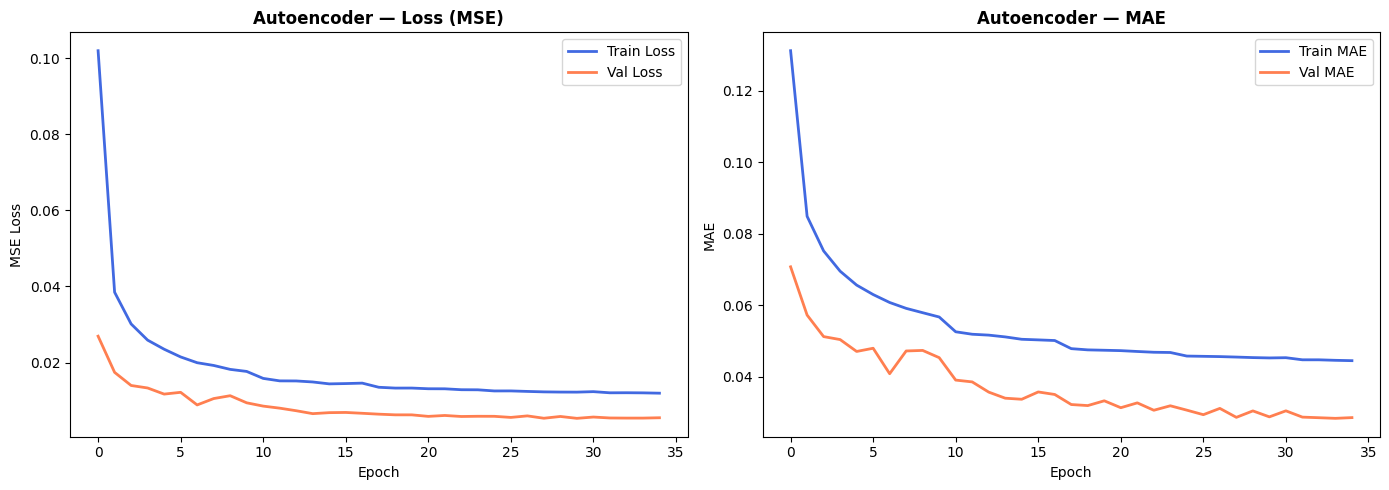

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['loss'],     label='Train Loss', color='royalblue', lw=2)
ax1.plot(history.history['val_loss'], label='Val Loss',   color='coral',     lw=2)
ax1.set_title("Autoencoder — Loss (MSE)", fontweight='bold')
ax1.set_xlabel("Epoch")
ax1.set_ylabel("MSE Loss")
ax1.legend()

ax2.plot(history.history['mae'],     label='Train MAE', color='royalblue', lw=2)
ax2.plot(history.history['val_mae'], label='Val MAE',   color='coral',     lw=2)
ax2.set_title("Autoencoder — MAE", fontweight='bold')
ax2.set_xlabel("Epoch")
ax2.set_ylabel("MAE")
ax2.legend()

plt.tight_layout()
plt.savefig("../reports/autoencoder_training.png", dpi=150)
plt.show()

In [7]:
# Reconstruction error = how badly the model fails to reconstruct input
# High error = anomaly = likely attack

# Get reconstruction errors for benign and attack samples
X_b_recon = autoencoder.predict(X_benign[:50000], batch_size=2048, verbose=0)
X_a_recon = autoencoder.predict(X_attack[:50000], batch_size=2048, verbose=0)

# Mean Squared Error per sample
mse_benign = np.mean(np.power(X_benign[:50000] - X_b_recon, 2), axis=1)
mse_attack = np.mean(np.power(X_attack[:50000] - X_a_recon, 2), axis=1)

print(f"Benign MSE  — mean: {mse_benign.mean():.4f} | max: {mse_benign.max():.4f}")
print(f"Attack MSE  — mean: {mse_attack.mean():.4f} | max: {mse_attack.max():.4f}")
print(f"\n✅ Attack MSE is {'higher' if mse_attack.mean() > mse_benign.mean() else 'lower'} than Benign MSE")
print("→ This means the autoencoder can distinguish attacks from normal traffic!")

Benign MSE  — mean: 0.0139 | max: 15.1001
Attack MSE  — mean: 0.3841 | max: 3.0744

✅ Attack MSE is higher than Benign MSE
→ This means the autoencoder can distinguish attacks from normal traffic!


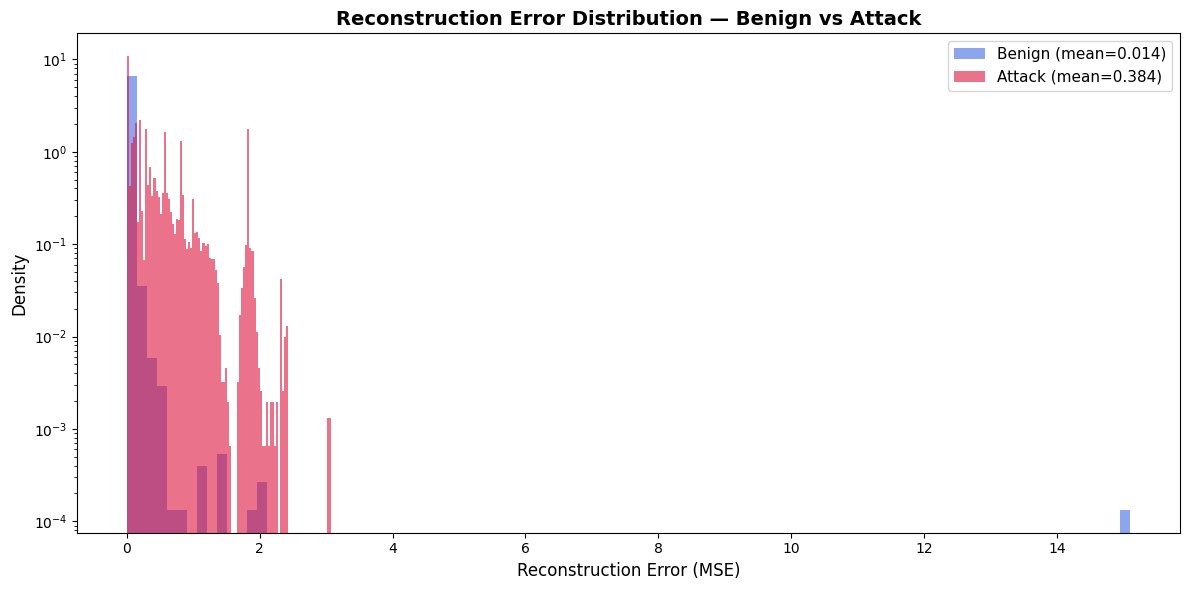

In [8]:
plt.figure(figsize=(12, 6))

plt.hist(mse_benign, bins=100, alpha=0.6, color='royalblue',
         label=f'Benign (mean={mse_benign.mean():.3f})', density=True)
plt.hist(mse_attack, bins=100, alpha=0.6, color='crimson',
         label=f'Attack (mean={mse_attack.mean():.3f})', density=True)

plt.xlabel("Reconstruction Error (MSE)", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.title("Reconstruction Error Distribution — Benign vs Attack", fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.yscale('log')
plt.tight_layout()
plt.savefig("../reports/autoencoder_reconstruction_error.png", dpi=150)
plt.show()

In [9]:
# Combine samples for threshold finding
X_combined = np.vstack([X_benign[:50000], X_attack[:50000]])
y_combined  = np.array([0]*50000 + [1]*50000)

recon = autoencoder.predict(X_combined, batch_size=2048, verbose=0)
mse_all = np.mean(np.power(X_combined - recon, 2), axis=1)

# Find best threshold using precision-recall curve
precisions, recalls, thresholds = precision_recall_curve(y_combined, mse_all)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"✅ Best threshold    : {best_threshold:.6f}")
print(f"   Best F1 Score    : {f1_scores[best_idx]*100:.2f}%")
print(f"   Precision        : {precisions[best_idx]*100:.2f}%")
print(f"   Recall           : {recalls[best_idx]*100:.2f}%")

# Save threshold
joblib.dump(best_threshold, '../models/saved/autoencoder_threshold.pkl')
print(f"\n✅ Threshold saved to models/saved/autoencoder_threshold.pkl")

✅ Best threshold    : 0.003733
   Best F1 Score    : 77.84%
   Precision        : 67.81%
   Recall           : 91.35%

✅ Threshold saved to models/saved/autoencoder_threshold.pkl


In [10]:
# Reconstruct test set
X_test_recon = autoencoder.predict(X_test, batch_size=2048, verbose=0)
mse_test = np.mean(np.power(X_test - X_test_recon, 2), axis=1)

# Classify using threshold
y_pred_ae = (mse_test > best_threshold).astype(int)

print("=" * 55)
print("  AUTOENCODER — Test Set Results")
print("=" * 55)
print(f"  Accuracy  : {accuracy_score(y_test, y_pred_ae)*100:.2f}%")
print(f"  F1 Score  : {f1_score(y_test, y_pred_ae)*100:.2f}%")
print(f"  ROC-AUC   : {roc_auc_score(y_test, mse_test)*100:.2f}%")
print("=" * 55)

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred_ae,
      target_names=['Benign', 'Attack'], digits=4))

  AUTOENCODER — Test Set Results
  Accuracy  : 82.88%
  F1 Score  : 79.44%
  ROC-AUC   : 93.81%

=== Classification Report ===
              precision    recall  f1-score   support

      Benign     0.9185    0.7967    0.8533    142310
      Attack     0.7225    0.8822    0.7944     85385

    accuracy                         0.8288    227695
   macro avg     0.8205    0.8394    0.8238    227695
weighted avg     0.8450    0.8288    0.8312    227695



[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.2s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.7s finished


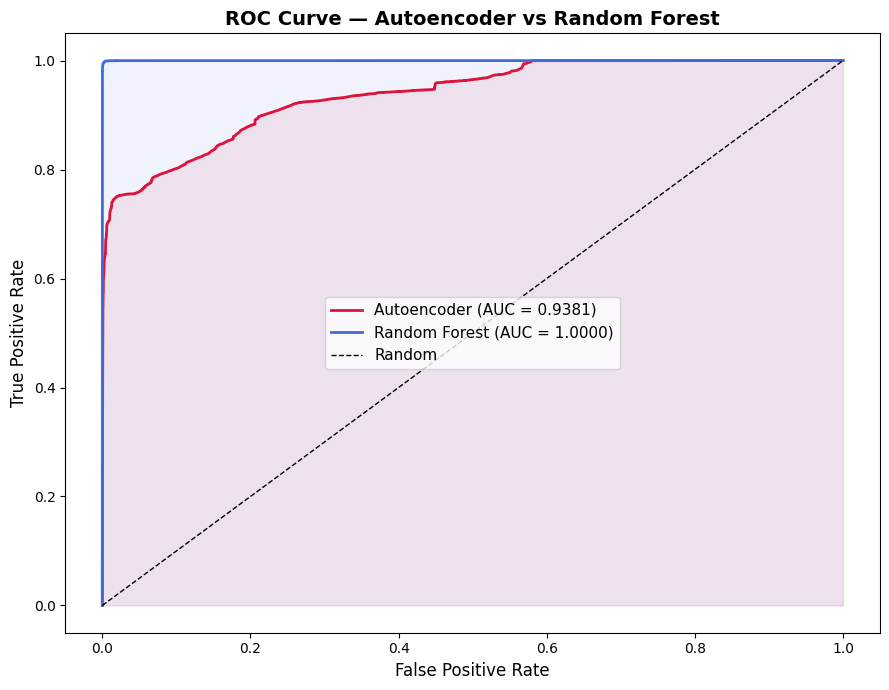

In [11]:
# Load RF results for comparison
rf_binary = joblib.load("../models/saved/rf_binary.pkl")
y_prob_rf = rf_binary.predict_proba(X_test)[:, 1]

fpr_ae, tpr_ae, _ = roc_curve(y_test, mse_test)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

auc_ae = roc_auc_score(y_test, mse_test)
auc_rf = roc_auc_score(y_test, y_prob_rf)

plt.figure(figsize=(9, 7))
plt.plot(fpr_ae, tpr_ae, lw=2, color='crimson',
         label=f'Autoencoder (AUC = {auc_ae:.4f})')
plt.plot(fpr_rf, tpr_rf, lw=2, color='royalblue',
         label=f'Random Forest (AUC = {auc_rf:.4f})')
plt.plot([0,1],[0,1], 'k--', lw=1, label='Random')
plt.fill_between(fpr_ae, tpr_ae, alpha=0.08, color='crimson')
plt.fill_between(fpr_rf, tpr_rf, alpha=0.08, color='royalblue')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve — Autoencoder vs Random Forest', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig("../reports/autoencoder_vs_rf_roc.png", dpi=150)
plt.show()

In [13]:
# Save in .keras format (compatible with newer Keras)
autoencoder.save("../models/saved/autoencoder_final.keras")

print("✅ All autoencoder files saved:")
model_path = "../models/saved/"
for f in sorted(os.listdir(model_path)):
    size = os.path.getsize(model_path + f) / (1024*1024)
    print(f"  {f:40s} {size:.2f} MB")

✅ All autoencoder files saved:
  autoencoder_best.h5                      0.47 MB
  autoencoder_final.h5                     0.47 MB
  autoencoder_final.keras                  0.46 MB
  autoencoder_threshold.pkl                0.00 MB
  label_encoder.pkl                        0.00 MB
  rf_binary.pkl                            15.98 MB
  rf_multi.pkl                             58.88 MB
  scaler.pkl                               0.00 MB
  selected_features.pkl                    0.00 MB
  xgb_binary.pkl                           0.53 MB
